# **02 - Exploratory Data Analysis (EDA)**

This notebook performs a comprehensive EDA of the BOPB (Butlletí Oficial de la Província de Barcelona)
dataset to understand the challenges of the multilabel ODS classification task.

**Input:** `full_dataset.parquet` — exported by notebook 01 *before* any filtering or preprocessing,
so the EDA reflects the raw data landscape. Filtering (keep only announcements with ≥1 ODS)
is replicated here for label-related analyses.

### **Contents:**
1. Imports & Configuration
2. Dataset Overview
3. ODS Label Distribution
4. Multilabel Complexity Metrics (Label Cardinality & Density)
5. Text Length Analysis
6. ODS Label Co-occurrence
7. Text Quality & OCR Artefact Detection
8. Thematic Word Cloud

## **1. Imports & Configuration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
from collections import Counter
from itertools import combinations
from wordcloud import WordCloud
from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from utils import OUTPUT_DIR, OUTPUT_DIR_EDA, ODS_ALL, ODS_COLORS
from schema import Metadata, ProcessedData

# Create analysis output directory if it does not exist
os.makedirs(OUTPUT_DIR_EDA, exist_ok=True)

# Visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## **2. Dataset Overview**

`full_dataset.parquet` is the raw integrated dataset exported by notebook 01 **before** any
filtering or text preprocessing. It contains all announcements, including those without any ODS label.

For label-related analyses (sections 3–6) we apply the same filter used in notebook 01:
keeping only announcements with at least one ODS assigned.
Label binarization is also performed here locally, mirroring the `MultiLabelBinarizer`
fitted in notebook 01.

In [2]:
# Load the full dataset produced by notebook 01 (pre-filtering, pre-preprocessing)
df_full = pd.read_parquet(os.path.join(OUTPUT_DIR, 'full_dataset.parquet'))

print(f'Full dataset shape (all announcements): {df_full.shape}')
print(f'Columns: {df_full.columns.tolist()}')
df_full.head()

Full dataset shape (all announcements): (35520, 10)
Columns: ['ANH_ID', 'ANU_DATA_PUBLICACIO', 'ANU_NUM_REGISTRE', 'ORG_NOM', 'ANH_TITOL', 'Tipus Anunci', 'PDF', 'ods_list', 'text', 'full_text']


,ANH_ID,ANU_DATA_PUBLICACIO,ANU_NUM_REGISTRE,ORG_NOM,ANH_TITOL,Tipus Anunci,PDF,ods_list,text,full_text
0,3016795,2022-02-08 00:00:00,202210011035,Jutjat Social núm. 3 de Sabadell,Edicte de notificació de decret de les actuaci...,Jurisdicció Laboral,https://bop.diba.cat/anunci/3016795,[],EDICTO Juzgado de lo Social nº 3 de Sabadell C...,Edicte de notificació de decret de les actuaci...
1,3090350,2022-01-14 00:00:00,202110088040,Jutjat Social núm. 27 de Barcelona,Edicte de notificació de citació el 17.01.2022...,Jurisdicció Laboral,https://bop.diba.cat/anunci/3090350,[],EDICTO Juzgado de lo Social nº 27 de Barcelona...,Edicte de notificació de citació el 17.01.2022...
2,3152365,2022-03-10 00:00:00,202110139580,Jutjat Social núm. 24 de Barcelona,Edicte de notificació de citació el 10.03.2022...,Jurisdicció Laboral,https://bop.diba.cat/anunci/3152365,[],EDICTO Juzgado de lo Social nº 24 de Barcelona...,Edicte de notificació de citació el 10.03.2022...
3,3164025,2022-01-18 00:00:00,202210001485,Jutjat Social núm. 27 de Barcelona,Edicte de notificació de sentència de les actu...,Jurisdicció Laboral,https://bop.diba.cat/anunci/3164025,[],EDICTO Juzgado de lo Social nº 27 de Barcelona...,Edicte de notificació de sentència de les actu...
4,3164474,2022-01-18 00:00:00,202210001479,Jutjat Social núm. 27 de Barcelona,Edicte de notificació de resolució de les actu...,Jurisdicció Laboral,https://bop.diba.cat/anunci/3164474,[],EDICTO Juzgado de lo Social nº 27 de Barcelona...,Edicte de notificació de resolució de les actu...


In [3]:
# Replicate the filter from notebook 01: keep only announcements with at least one ODS
df = df_full[df_full[ProcessedData.ODS_LIST].apply(len) > 0].copy()

n_no_label = len(df_full) - len(df)
print(f'Announcements with at least one ODS : {len(df):,}  ({len(df)/len(df_full)*100:.1f}%)')
print(f'Announcements without any ODS (excl): {n_no_label:,}  ({n_no_label/len(df_full)*100:.1f}%)')

# Binarize ODS labels — mirrors the MultiLabelBinarizer fitted in notebook 01.
# classes=ODS_ALL ensures the column order is consistent across notebooks.
mlb = MultiLabelBinarizer(classes=ODS_ALL)
Y   = mlb.fit_transform(df[ProcessedData.ODS_LIST])
Y_df = pd.DataFrame(Y, columns=ODS_ALL, index=df.index)

print(f'\nLabel matrix shape: {Y.shape}  ({Y.shape[1]} ODSs x {Y.shape[0]} announcements)')

Announcements with at least one ODS : 19,284  (54.3%)
Announcements without any ODS (excl): 16,236  (45.7%)

Label matrix shape: (19284, 17)  (17 ODSs x 19284 announcements)


## **3. ODS Label Distribution**

We visualize how many announcements are associated with each of the 17 ODSs.
Because this is a multilabel problem, a single announcement can contribute to multiple ODS counts
simultaneously. Identifying the most and least frequent labels is essential to understand
class imbalance, which directly affects model training and evaluation strategy.

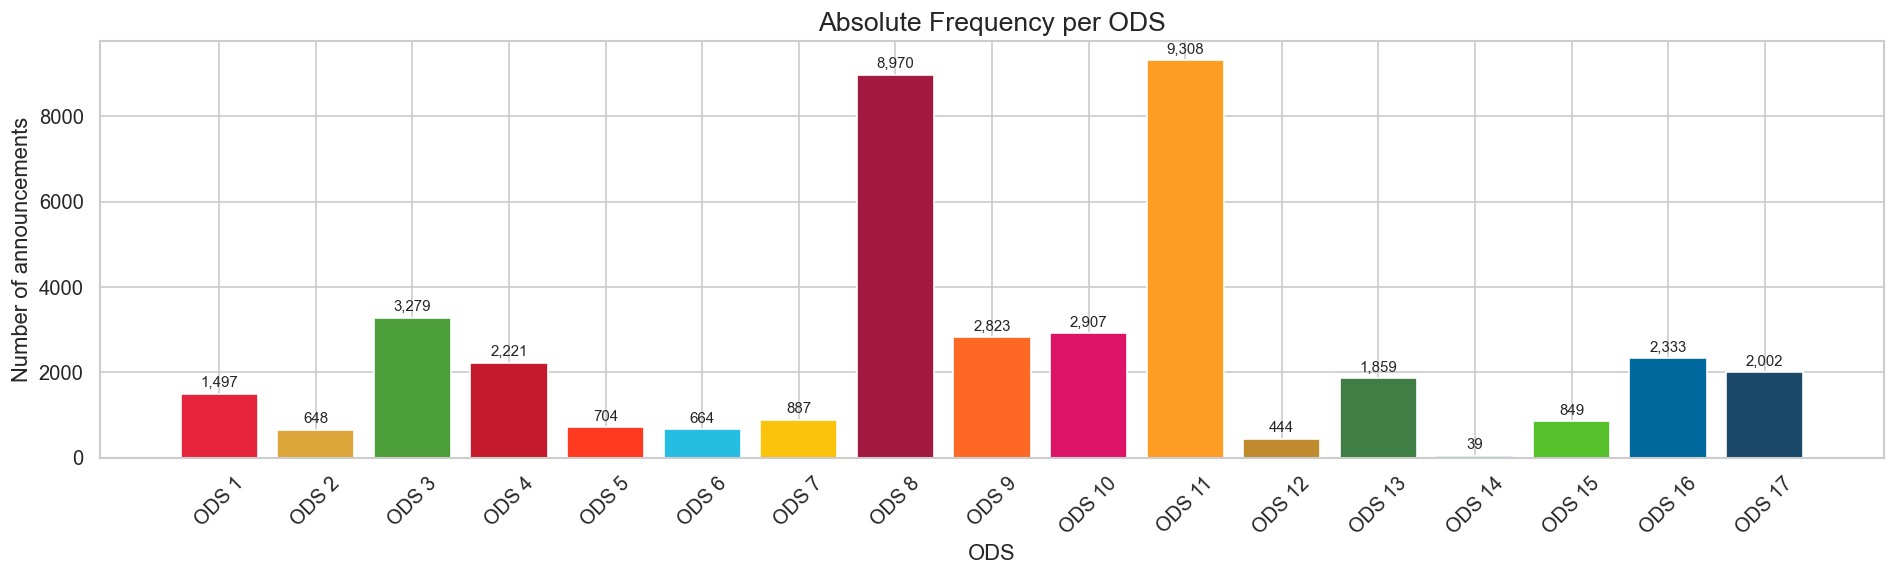

In [4]:
# Compute absolute label frequency from the binarized matrix
label_counts = Y_df.sum().reindex(ODS_ALL)
label_freq   = label_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=[ODS_COLORS[ods] for ods in label_counts.index]
)

# Add count annotation on top of each bar
for bar, count in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts.max() * 0.01,
        f'{int(count):,}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Absolute Frequency per ODS', fontsize=16)
ax.set_xlabel('ODS')
ax.set_ylabel('Number of announcements')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_label_distribution.png'), bbox_inches='tight')
plt.show()

In [5]:
# Print the most and least frequent ODSs and the overall imbalance ratio
label_sorted = label_counts.sort_values(ascending=False)
print('Top 5 most frequent ODSs:')
print(label_sorted.head().to_string())
print('\nTop 5 least frequent ODSs:')
print(label_sorted.tail().to_string())

Top 5 most frequent ODSs:
ODS 11    9308
ODS 8     8970
ODS 3     3279
ODS 10    2907
ODS 9     2823

Top 5 least frequent ODSs:
ODS 5     704
ODS 6     664
ODS 2     648
ODS 12    444
ODS 14     39


## **4. Multilabel Complexity Metrics**

Standard classification metrics assume each sample has exactly one label.
In a multilabel setting, we need specific measures to quantify the complexity of the label space:

- **Label Cardinality (LC):** Average number of labels per announcement. A value of 1 means every
  announcement has exactly one ODS; higher values indicate more multi-assignment.
- **Label Density (LD):** LC normalized by the total number of labels (17). Ranges from 0 to 1;
  values close to 0 indicate a sparse label space.
- **Unique labelsets:** Number of distinct label combinations present in the dataset. A high number
  relative to the dataset size makes Label Powerset approaches harder to apply.
- **Proportion of unique labelsets:** Ratio of unique labelsets to total announcements. Values close
  to 1 mean almost every announcement has a unique combination.

In [6]:
# Label cardinality: average number of ODSs per announcement
labels_per_sample = Y.sum(axis=1)
label_cardinality = labels_per_sample.mean()

# Label density: cardinality normalized by total number of ODSs
label_density = label_cardinality / len(ODS_ALL)

# Unique labelsets and their proportion
labelsets = [tuple(row) for row in Y]
n_unique_labelsets = len(set(labelsets))
prop_unique = n_unique_labelsets / len(df)

print('=== Multilabel Complexity Metrics ===')
print(f'Label Cardinality (LC):          {label_cardinality:.4f}')
print(f'Label Density (LD):              {label_density:.4f}')
print(f'Unique labelsets:                {n_unique_labelsets:,}')
print(f'Proportion of unique labelsets:  {prop_unique:.4f}')
print(f'Announcements with 1 label:      {(labels_per_sample == 1).sum():,}')
print(f'Announcements with 2+ labels:    {(labels_per_sample > 1).sum():,}')
print(f'Max labels in one announcement:  {int(labels_per_sample.max())}')

=== Multilabel Complexity Metrics ===
Label Cardinality (LC):          2.1486
Label Density (LD):              0.1264
Unique labelsets:                1,042
Proportion of unique labelsets:  0.0540
Announcements with 1 label:      9,484
Announcements with 2+ labels:    9,800
Max labels in one announcement:  17


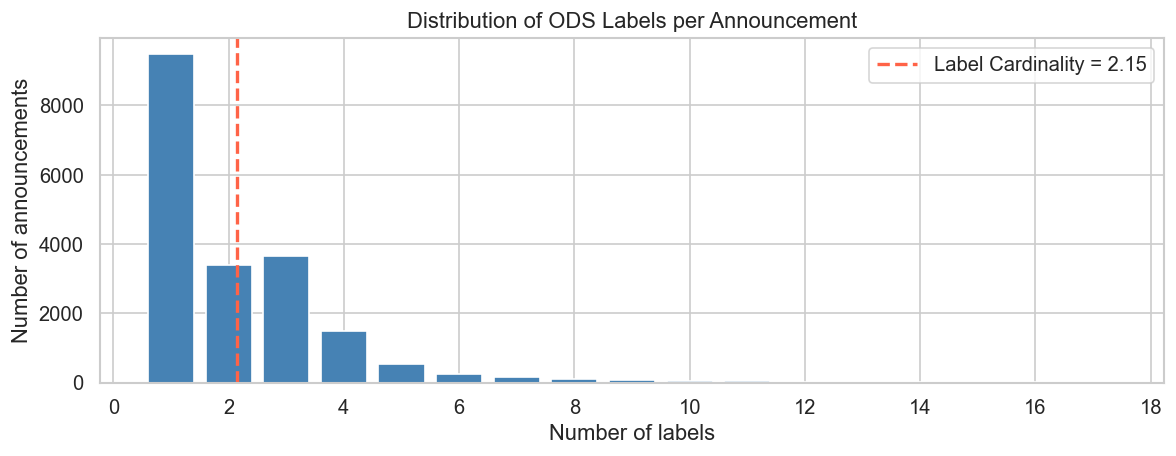

In [7]:
# Distribution of the number of ODS labels per announcement
fig, ax = plt.subplots(figsize=(10, 4))
counts = pd.Series(labels_per_sample).value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.axvline(label_cardinality, color='tomato', linewidth=2, linestyle='--',
           label=f'Label Cardinality = {label_cardinality:.2f}')
ax.set_title('Distribution of ODS Labels per Announcement')
ax.set_xlabel('Number of labels')
ax.set_ylabel('Number of announcements')
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_labels_per_sample.png'), bbox_inches='tight')
plt.show()

## **5. Text Length Analysis**

The length of the input text directly affects model choice and tokenization strategy.
Very short texts may lack enough semantic content for classification, while very long texts
may exceed the maximum sequence length of Transformer models (typically 512 tokens for BERT-based models).

**Note:** Length is measured on `full_text` — the raw concatenation of title and body produced
in notebook 01, **before** the ML or DL preprocessing steps. This gives the most accurate
picture of the original data distribution. The DL pipeline receives `text_dl` (only `clean_base`
applied, which does not change length significantly), while the ML pipeline truncates at
200,000 characters before spaCy lemmatization.

This section also flags announcements that are suspiciously short, which may indicate
PDF extraction or OCR failures in the original source documents.

In [8]:
# Compute character and word-level lengths on the raw full_text
df['text_len_chars'] = df[ProcessedData.FULL_TEXT].str.len()
df['text_len_words'] = df[ProcessedData.FULL_TEXT].str.split().str.len()

print('=== Text Length Statistics (raw full_text) ===')
print(df[['text_len_chars', 'text_len_words']].describe().round(1))

=== Text Length Statistics (raw full_text) ===
       text_len_chars  text_len_words
count         19284.0         19284.0
mean          18274.9          2801.0
std           40644.1          6120.8
min              48.0             8.0
25%            1536.8           237.0
50%            3568.0           549.5
75%           26246.0          4040.0
max         1444585.0        200427.0


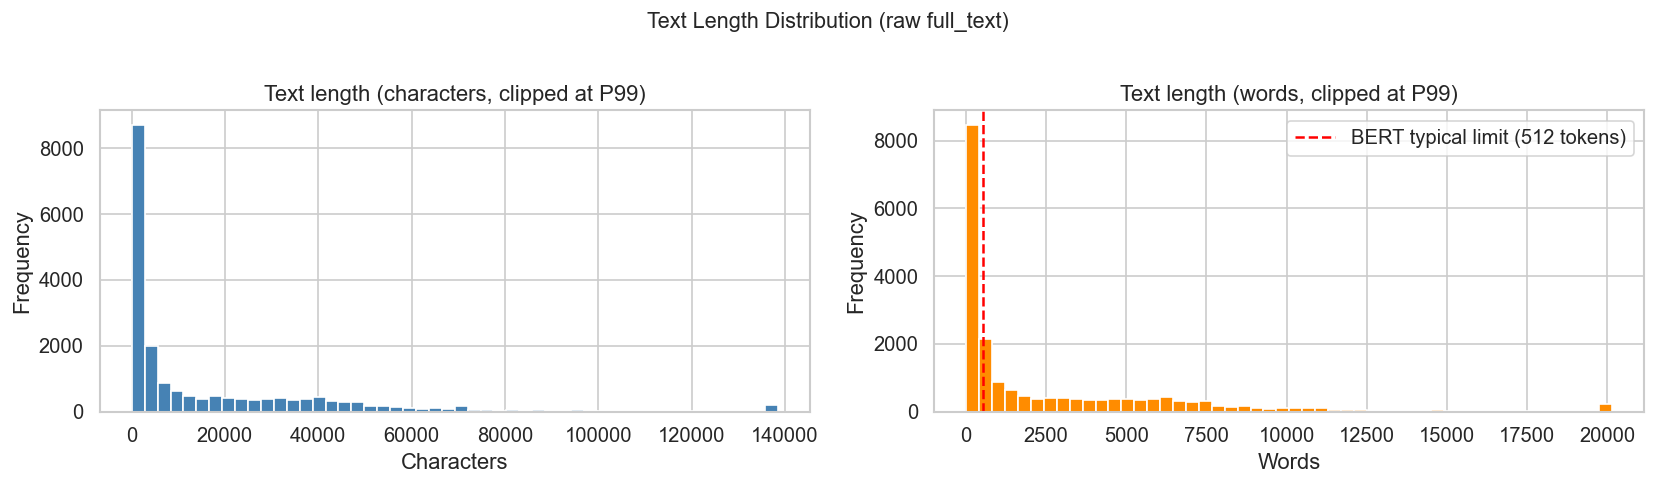

Announcements exceeding ML truncation limit (200,000 chars): 0.46%
Announcements with fewer than 50 words: 0.5%  — possible OCR errors


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character-level distribution (clipped at P99 to avoid extreme outliers distorting the plot)
axes[0].hist(
    df['text_len_chars'].clip(upper=df['text_len_chars'].quantile(0.99)),
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('Text length (characters, clipped at P99)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# Word-level distribution with BERT 512-token reference line
axes[1].hist(
    df['text_len_words'].clip(upper=df['text_len_words'].quantile(0.99)),
    bins=50, color='darkorange', edgecolor='white'
)
axes[1].axvline(x=512, color='red', linestyle='--', label='BERT typical limit (512 tokens)')
axes[1].set_title('Text length (words, clipped at P99)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Text Length Distribution (raw full_text)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_text_length.png'), bbox_inches='tight')
plt.show()

# Check how many announcements exceed the ML truncation limit applied in notebook 01
MAX_LEN = 200_000
pct_truncated = (df['text_len_chars'] > MAX_LEN).mean() * 100
short_threshold = 50
pct_short = (df['text_len_words'] < short_threshold).mean() * 100

print(f'Announcements exceeding ML truncation limit ({MAX_LEN:,} chars): {pct_truncated:.2f}%')
print(f'Announcements with fewer than {short_threshold} words: {pct_short:.1f}%  — possible OCR errors')

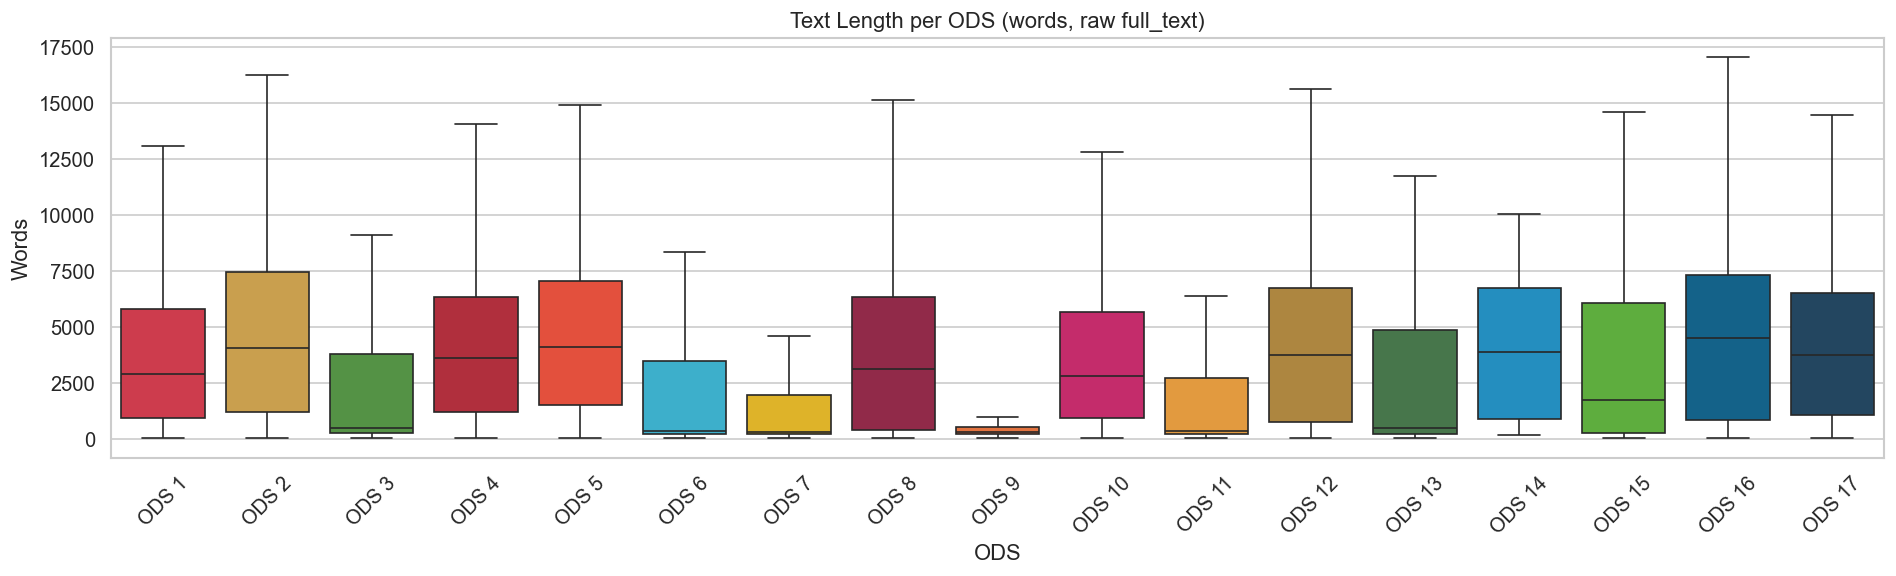

In [10]:
# Per-ODS text length boxplot — reveals whether certain ODSs correspond to shorter/longer texts
records = [
    {'ODS': ods, 'Words': v}
    for ods in ODS_ALL
    for v in df[Y_df[ods] == 1]['text_len_words']
]
df_box = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(
    data=df_box, x='ODS', y='Words', ax=ax,
    order=ODS_ALL,
    palette={ods: ODS_COLORS[ods] for ods in ODS_ALL},
    showfliers=False   # hide extreme outliers for readability
)
ax.set_title('Text Length per ODS (words, raw full_text)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_text_length_per_ods.png'), bbox_inches='tight')
plt.show()

## **6. ODS Label Co-occurrence**

Co-occurrence analysis reveals which ODSs tend to appear together in the same announcement.
This is relevant for two reasons:
1. It exposes semantic relationships between ODSs in the context of public administration.
2. It informs the choice of multilabel strategy — high co-occurrence between specific pairs
   may make Classifier Chains more effective than Binary Relevance, since chains can explicitly
   model label dependencies.

Two complementary views are provided: an absolute co-occurrence count matrix and a
Pearson correlation heatmap.

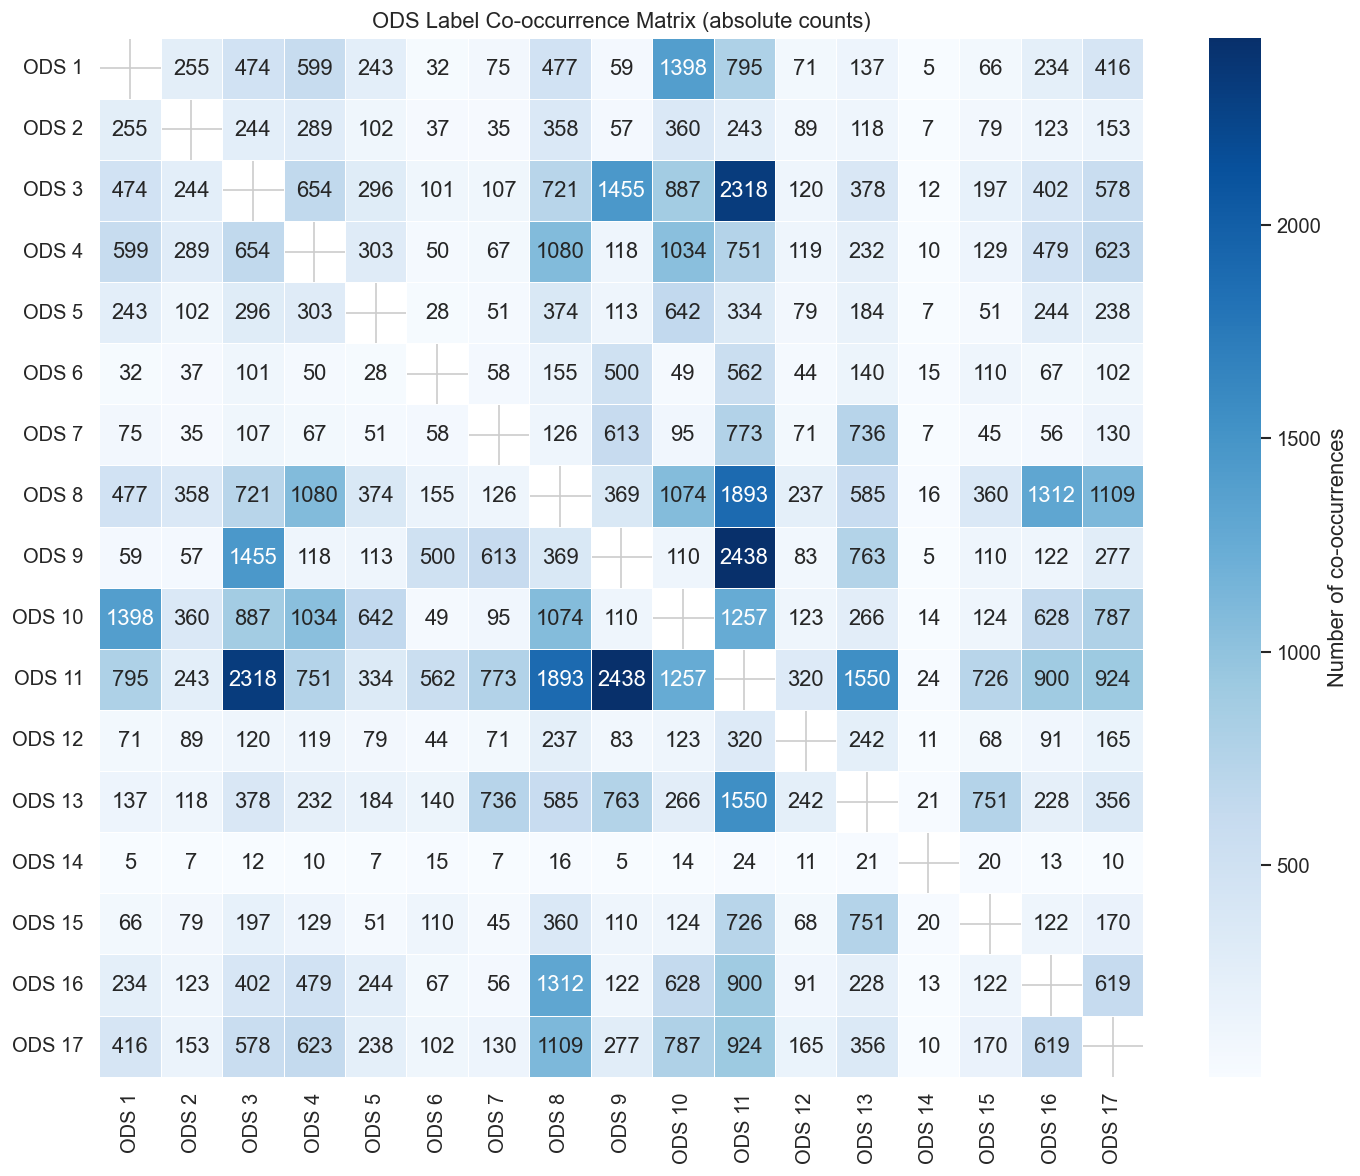

In [11]:
# Absolute co-occurrence matrix — built from the binarized Y matrix
co_matrix = Y_df.T.dot(Y_df)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(ODS_ALL), dtype=bool)  # hide diagonal (self-co-occurrence)
sns.heatmap(
    co_matrix, annot=True, fmt='d', cmap='Blues',
    mask=mask, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Number of co-occurrences'}
)
ax.set_title('ODS Label Co-occurrence Matrix (absolute counts)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_cooccurrence_matrix.png'), bbox_inches='tight')
plt.show()

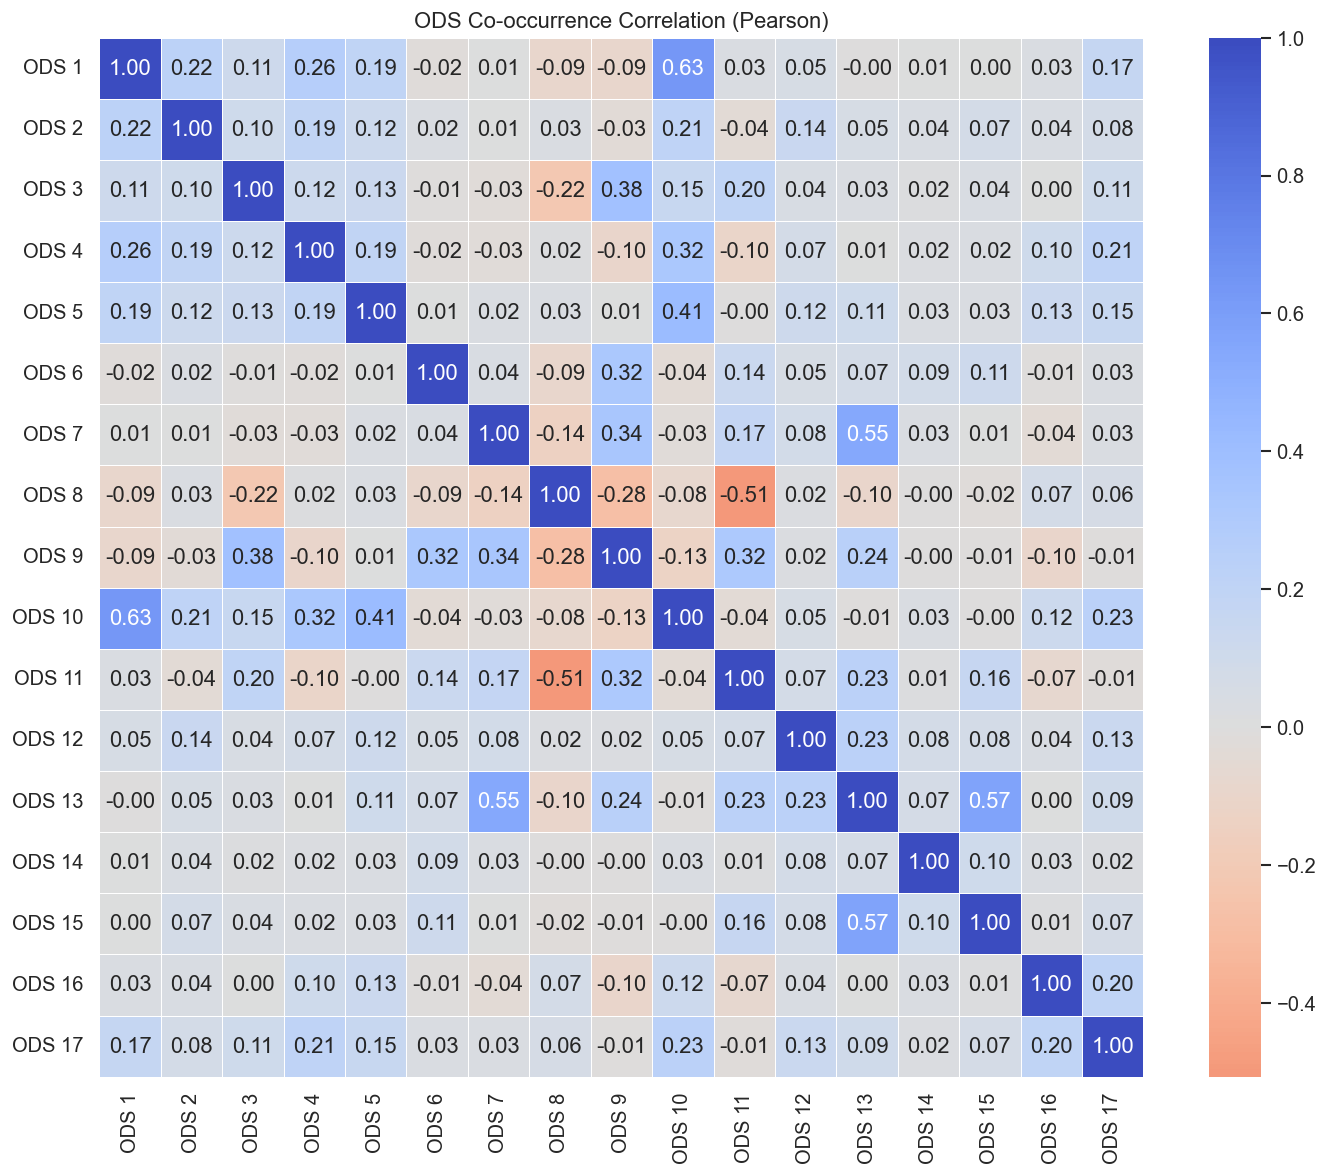

In [12]:
# Pearson correlation heatmap — normalizes co-occurrences by individual label frequency,
# making it easier to spot systematic associations between less frequent labels
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    Y_df.corr(), annot=True, fmt='.2f', cmap='coolwarm_r',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('ODS Co-occurrence Correlation (Pearson)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_cooccurrence_correlation.png'), bbox_inches='tight')
plt.show()

In [13]:
# Top ODS pairs that co-occur most frequently
# Iterating over ODS_LIST directly avoids re-binarizing and is more efficient
pair_counts = Counter()
for ods_list in df[ProcessedData.ODS_LIST]:
    for pair in combinations(sorted(ods_list), 2):
        pair_counts[pair] += 1

print('Top 10 most frequent ODS co-occurring pairs:')
for pair, cnt in pair_counts.most_common(10):
    print(f'  {pair[0]} + {pair[1]}: {cnt:,}')

Top 10 most frequent ODS co-occurring pairs:
  ODS 11 + ODS 9: 2,438
  ODS 11 + ODS 3: 2,318
  ODS 11 + ODS 8: 1,893
  ODS 11 + ODS 13: 1,550
  ODS 3 + ODS 9: 1,455
  ODS 1 + ODS 10: 1,398
  ODS 16 + ODS 8: 1,312
  ODS 10 + ODS 11: 1,257
  ODS 17 + ODS 8: 1,109
  ODS 4 + ODS 8: 1,080


## **7. Text Quality & OCR Artefact Detection**

The text in this dataset was extracted from PDF documents, which can introduce noise:
garbled characters, encoding errors, or non-standard symbols from imperfect OCR.
The presence of non-ASCII characters beyond standard accented letters used in
Catalan and Spanish is used here as a proxy for extraction quality.

A high non-ASCII ratio in a document suggests it may contain OCR artefacts that could
hurt model performance by introducing out-of-vocabulary tokens or corrupting semantic content.
Note that notebook 01's `clean_base` function normalizes Unicode (NFC) and strips control
characters, but does **not** remove legitimate accented letters — so a moderate baseline
non-ASCII ratio is expected for Catalan/Spanish text.

In [14]:
def non_ascii_ratio(text: str) -> float:
    """Returns the proportion of non-ASCII characters in a string.
    
    Standard Catalan/Spanish accents (á, é, ï, ç, etc.) are non-ASCII,
    so a moderate ratio is expected. Unusually high values suggest OCR noise.
    """
    if not isinstance(text, str) or not text:
        return 0.0
    non_ascii = sum(1 for c in text if ord(c) > 127)
    return non_ascii / len(text)


# Apply on raw full_text — before clean_base normalization from notebook 01
df['non_ascii_ratio'] = df[ProcessedData.FULL_TEXT].apply(non_ascii_ratio)

print('Non-ASCII character ratio statistics (raw full_text):')
print(df['non_ascii_ratio'].describe().round(4))

Non-ASCII character ratio statistics (raw full_text):
count    19284.0000
mean         0.0218
std          0.0042
min          0.0004
25%          0.0195
50%          0.0222
75%          0.0241
max          0.0673
Name: non_ascii_ratio, dtype: float64


In [15]:
# Show examples with a high ratio (potential extraction errors)
threshold = df['non_ascii_ratio'].quantile(0.95)
print(f'Announcements with ratio > {threshold:.4f} (top 5%):')
suspicious = df[df['non_ascii_ratio'] > threshold][[ProcessedData.FULL_TEXT, 'non_ascii_ratio']].head(5)
for _, row in suspicious.iterrows():
    print(f'  [{row["non_ascii_ratio"]:.3f}] {row[ProcessedData.FULL_TEXT][:200]}')
    print()

Announcements with ratio > 0.0280 (top 5%):
  [0.029] Aprovació definitiva del Projecte de construcció del dipòsit de suports especials de l'Arxiu del Pavelló de Suècia. EDICTE PROCEDIMENT X2021002793 MUNICIPAL DE CONSTRUCCIÓ DEL DIPÒSIT DE SUPORTS ESPEC

  [0.038] Aprovació inicial del Projecte bàsic i d'execució de nou aparcament del carrer València, en la parcel·la delimitada pel carrer València, avinguda Santiga i carrer Mossèn Camil Rossell. 

  [0.030] Aprovació de la convocatòria del Premi Poesia Martí Dot 2021. ANUNCI Mitjançant decret de lalcaldia núm. 3902 de data 28 de desembre de 2021, lajuntament ha resolt aprovar la convocatòria del Premi Po

  [0.031] Aprovació inicial de l'expedient de constitució de l'Agrupació de les entitats locals de Guardiola de Berguedà i Avià, per al sosteniment en comú del lloc de secretaria d'intervenció i els Estatuts qu

  [0.036] Convocatòria del procés selectiu, mitjançant concurs-oposició, per a la formació d'una borsa de treball de tècnic

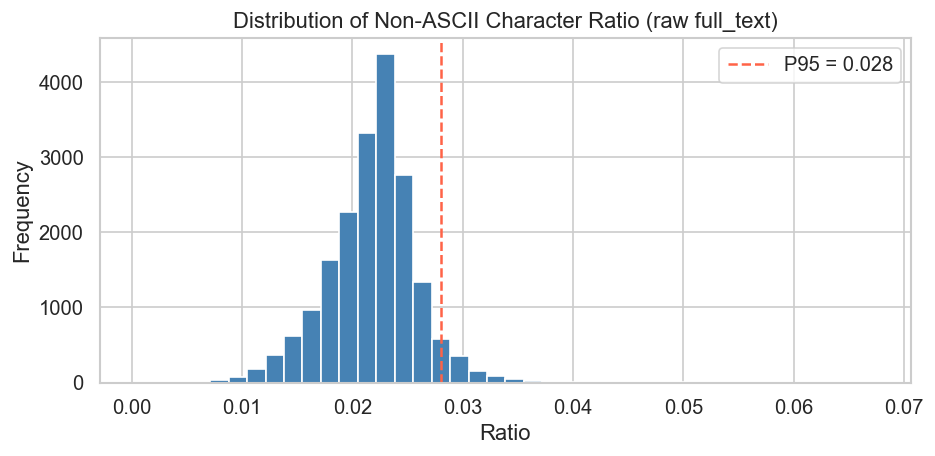

In [16]:
# Histogram of non-ASCII ratios with P95 threshold marker
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['non_ascii_ratio'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(threshold, color='tomato', linestyle='--', label=f'P95 = {threshold:.3f}')
ax.set_title('Distribution of Non-ASCII Character Ratio (raw full_text)')
ax.set_xlabel('Ratio')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_ocr_quality.png'), bbox_inches='tight')
plt.show()

## **8. Thematic Word Cloud**

A visual summary of the most frequent terms in the BOPB corpus, sampled from `full_text`.
Dominant terms reflect the institutional and administrative language of the dataset,
which is useful for contextualizing tokenization and stop-word decisions in the
ML preprocessing pipeline (`process_ml` in notebook 01 applies spaCy lemmatization
and stop-word removal on top of this raw text).

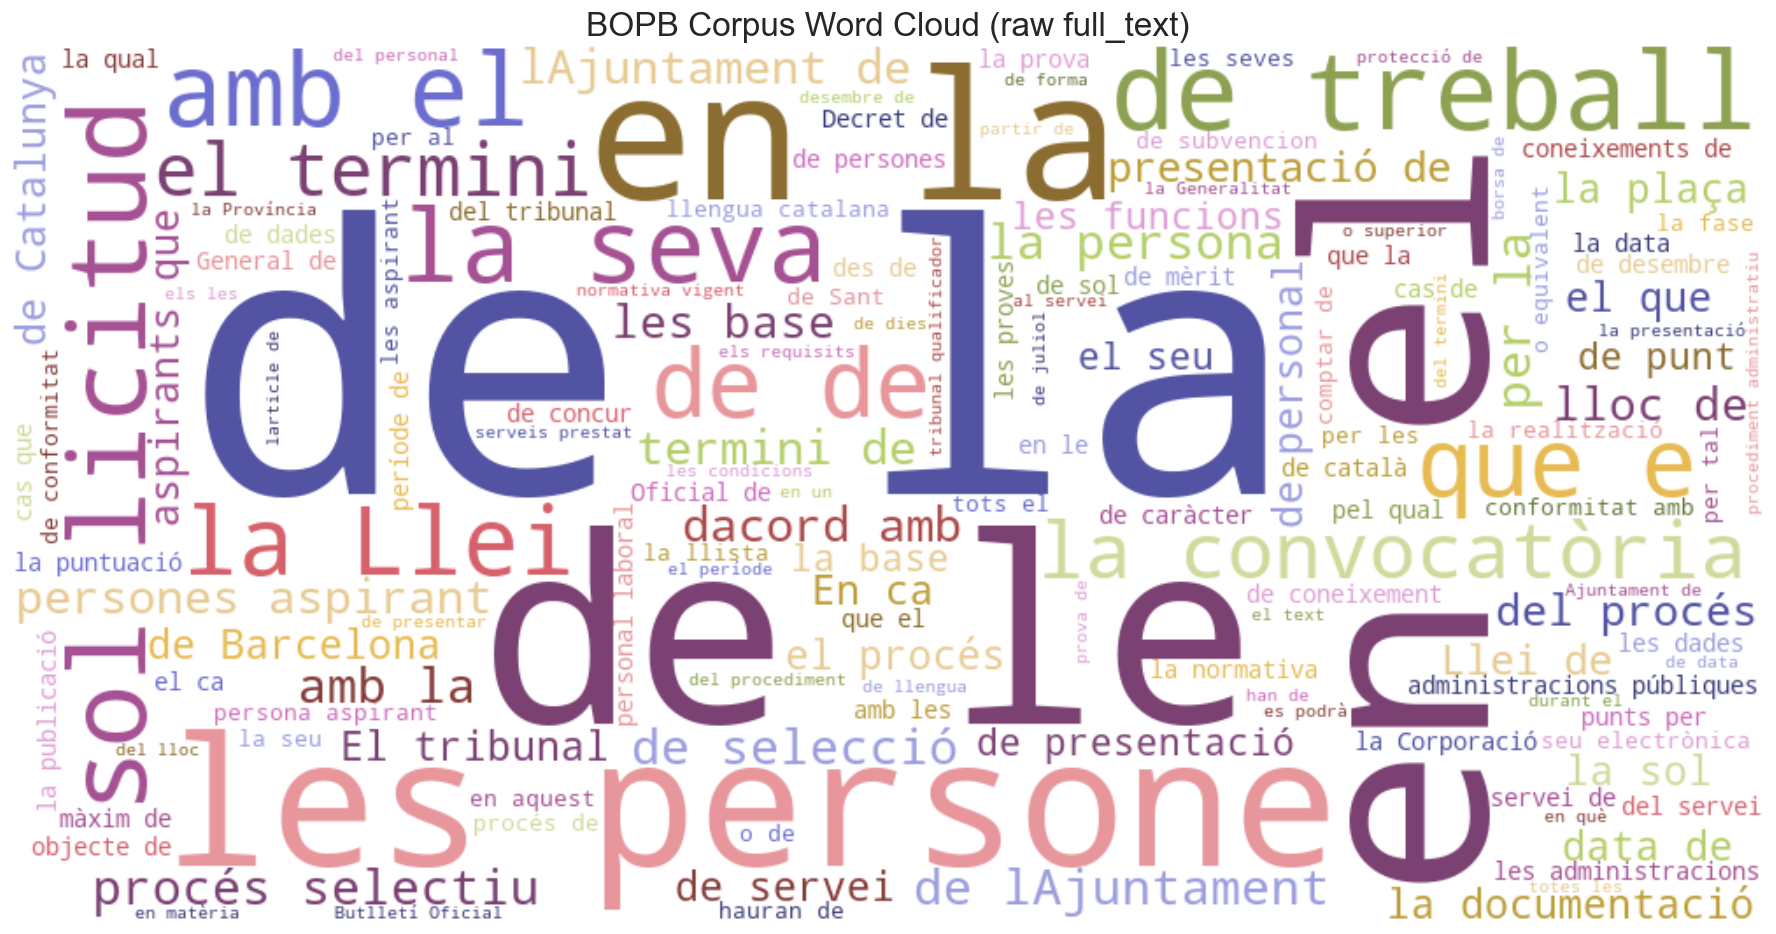

In [17]:
# Sample a subset for efficiency and generate the word cloud from raw full_text
sample_text = " ".join(
    df[ProcessedData.FULL_TEXT].sample(min(3000, len(df)), random_state=42).astype(str)
)

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='tab20b',
    max_words=150
).generate(sample_text)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('BOPB Corpus Word Cloud (raw full_text)', fontsize=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_EDA, 'eda_wordcloud.png'), bbox_inches='tight')
plt.show()